# Lid-driven cavity flow with TVD (Van Leer) convection on a Staggered MAC Grid

Combines the two improvements explored separately in `lid_driven_cavity_tvd.ipynb` (Van Leer TVD convection scheme) and `lid_driven_cavity_staggered.ipynb` (MAC staggered grid + direct sparse Poisson solve) into a single solver.

## Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import factorized

## Domain Setup

In [2]:
L = 1.0
N = 129    # number of cells (N×N pressure grid)
dx = L / N
dy = L / N

Re    = 100.0
U_lid = 1.0
Nu    = U_lid * L / Re

# ── Staggered MAC grid ─────────────────────────────────────────────────────
# p : (N,   N  ) — cell centres
# u : (N,   N+1) — vertical faces   u[i,j] at x=j·dx,     y=(i+0.5)·dy
# v : (N+1, N  ) — horizontal faces v[i,j] at x=(j+0.5)·dx, y=i·dy
p = np.zeros((N,   N  ))
u = np.zeros((N,   N+1))
v = np.zeros((N+1, N  ))

# Cell-centre grid for visualisation
x_c = (np.arange(N) + 0.5) * dx
y_c = (np.arange(N) + 0.5) * dy
X_c, Y_c = np.meshgrid(x_c, y_c)

# TVD needs CFL <= 0.5 per direction; use 0.4 for margin (same as lid_driven_cavity_tvd.ipynb)
safety_factor = 0.4
dt = safety_factor / (U_lid/dx + U_lid/dy + 4*Nu/dx**2)
CFL = U_lid * dt / dx
r   = Nu   * dt / dx**2

print(f"Grid : {N}×{N} cells | dx = {dx:.4f}")
print(f"dt   = {dt:.6f} | CFL = {CFL:.4f} | r = {r:.4f}")
print(f"Combined 2·CFL + 4r = {2*CFL + 4*r:.4f}  (≤ 1)")

nt = 30000
print(f"T_final = {nt*dt:.3f}")

Grid : 129×129 cells | dx = 0.0078
dt   = 0.000433 | CFL = 0.0559 | r = 0.0721
Combined 2·CFL + 4r = 0.4000  (≤ 1)
T_final = 12.992


In [3]:
# ── Build sparse Poisson matrix once (Neumann BCs, p[0,0]=0 reference) ────
def build_poisson_matrix(N, dx, dy):
    d = np.full(N, -2.0); d[0] = d[-1] = -1.0   # Neumann: half-stencil at walls
    e = np.ones(N - 1)
    Lx = diags([e, d, e], [-1, 0, 1], format='csr') / dx**2
    Ly = diags([e, d, e], [-1, 0, 1], format='csr') / dy**2
    I  = eye(N, format='csr')
    L  = kron(I, Lx, format='csr') + kron(Ly, I, format='csr')
    L  = L.tolil(); L[0, :] = 0; L[0, 0] = 1   # pin p[0,0] = 0
    return L.tocsr()

A_poisson   = build_poisson_matrix(N, dx, dy)
solve_poisson = factorized(A_poisson.tocsc())   # pre-factor LU once; each call is ~O(N²)
print(f"Poisson matrix {A_poisson.shape} built and LU-factorized.")

Poisson matrix (16641, 16641) built and LU-factorized.


## Algorithm Per Time Step

## Apply boundary conditions to u, v

In [4]:
def apply_boundary_conditions(u, v, U_lid=1.0):
    # u and v sit ON the faces, so normal-velocity BCs are enforced directly.
    # Tangential no-slip is handled via image (ghost) cells inside momentum_predictor.
    u[:, 0]  = 0.0   # left  wall — no penetration
    u[:, -1] = 0.0   # right wall — no penetration
    v[0,  :] = 0.0   # bottom wall — no penetration
    v[-1, :] = 0.0   # top wall   — lid moves in x only (v=0 here)
    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

Van Leer TVD convection in flux-difference form, adapted to the MAC grid:
- `u` is convected in x by itself, and in y by `v` interpolated to the north/south sub-faces of each u-cell.
- `v` is convected in y by itself, and in x by `u` interpolated to the east/west sub-faces of each v-cell.
- West/south faces reuse the east/north face value of the upwind neighbour (face sharing) for the
  positive-carrier branch, exactly mirroring the structure of `lid_driven_cavity_tvd.ipynb`.
- Tangential no-slip walls are enforced with two layers of mirror (image) ghost cells — one layer
  for the ordinary north/south (or east/west) neighbour, a second layer for the extra point the
  TVD limiter's negative-carrier branch needs ('far' neighbour).

In [ ]:
def van_leer(r):
    return (r + np.abs(r)) / (1 + np.abs(r))


def momentum_predictor(u, v, p, dx, dy, dt, Nu, U_lid, N):
    un = u.copy()
    vn = v.copy()
    u_star = un.copy()
    v_star = vn.copy()
    # Regularizer for the TVD slope ratios. Near steady state, both the
    # numerator and denominator of r shrink toward zero (flat regions /
    # corner vortices), so a bare div-by-zero guard (1e-10) lets r be
    # dominated by floating-point roundoff and the limiter chatters.
    # Scaling eps to a small but physically meaningful velocity difference
    # damps that chatter without affecting the limiter where gradients are
    # actually significant.
    eps = 1e-6

    # ===================== u-momentum =====================
    # u_ext: 2 ghost rows top & bottom (tangential no-slip, mirror images)
    #   layer 1 -> ordinary north/south neighbour   layer 2 -> TVD 'far' neighbour
    u_ext = np.empty((N + 4, N + 1))
    u_ext[2:-2, :] = un
    u_ext[1,  :] = -un[0, :]              # row -1  (bottom no-slip, avg -> 0)
    u_ext[0,  :] = -un[1, :]              # row -2
    u_ext[-2, :] = 2*U_lid - un[-1, :]    # row N   (top no-slip, avg -> U_lid)
    u_ext[-1, :] = 2*U_lid - un[-2, :]    # row N+1

    u_p  = u_ext[2:-2, 1:-1]   # un[:, 1:-1]                 (N, N-1)
    u_e  = un[:, 2:]                                          # (N, N-1)
    u_w  = un[:, :-2]                                         # (N, N-1)
    u_n  = u_ext[3:-1, 1:-1]   # row i+1 (top ghost if needed) (N, N-1)
    u_s  = u_ext[1:-3, 1:-1]   # row i-1 (bottom ghost if needed)(N, N-1)
    u_nn = u_ext[4:,   1:-1]   # row i+2 (TVD far, top)        (N, N-1)
    u_ee = np.empty_like(u_p)  # col j+2 (TVD far, right wall mirror at last col)
    u_ee[:, :-1] = un[:, 3:]
    u_ee[:, -1]  = -un[:, -2]

    # v interpolated to the north / south sub-faces of each u-cell (2-point x-average
    # of v at the row that coincides with that sub-face — exact for the MAC layout)
    v_at_uN = 0.5 * (vn[1:, :-1] + vn[1:, 1:])    # (N, N-1)
    v_at_uS = 0.5 * (vn[:-1, :-1] + vn[:-1, 1:])  # (N, N-1)

    # --- x-direction: east/west faces, carried by u itself ---
    r_e_pos = (u_p - u_w) / (u_e - u_p + eps)
    face_e_pos = u_p + 0.5 * van_leer(r_e_pos) * (u_p - u_w)
    r_e_neg = (u_e - u_ee) / (u_p - u_e + eps)
    face_e_neg = u_e + 0.5 * van_leer(r_e_neg) * (u_e - u_ee)
    carrier_ue = 0.5 * (u_p + u_e)
    F_u_e = np.maximum(carrier_ue, 0) * face_e_pos + np.minimum(carrier_ue, 0) * face_e_neg

    face_w_pos = np.empty_like(u_p)
    face_w_pos[:, 1:] = face_e_pos[:, :-1]; face_w_pos[:, 0] = u_w[:, 0]
    r_w_neg = (u_p - u_e) / (u_w - u_p + eps)
    face_w_neg = u_p + 0.5 * van_leer(r_w_neg) * (u_p - u_e)
    carrier_uw = 0.5 * (u_p + u_w)
    F_u_w = np.maximum(carrier_uw, 0) * face_w_pos + np.minimum(carrier_uw, 0) * face_w_neg

    conv_ux = (F_u_e - F_u_w) / dx

    # --- y-direction: north/south faces, carried by v interpolated to u ---
    r_n_pos = (u_p - u_s) / (u_n - u_p + eps)
    face_n_pos = u_p + 0.5 * van_leer(r_n_pos) * (u_p - u_s)
    r_n_neg = (u_n - u_nn) / (u_p - u_n + eps)
    face_n_neg = u_n + 0.5 * van_leer(r_n_neg) * (u_n - u_nn)
    F_u_n = np.maximum(v_at_uN, 0) * face_n_pos + np.minimum(v_at_uN, 0) * face_n_neg

    face_s_pos = np.empty_like(u_p)
    face_s_pos[1:, :] = face_n_pos[:-1, :]; face_s_pos[0, :] = u_s[0, :]
    r_s_neg = (u_p - u_n) / (u_s - u_p + eps)
    face_s_neg = u_p + 0.5 * van_leer(r_s_neg) * (u_p - u_n)
    F_u_s = np.maximum(v_at_uS, 0) * face_s_pos + np.minimum(v_at_uS, 0) * face_s_neg

    conv_uy = (F_u_n - F_u_s) / dy

    diff_u = Nu * ((u_e - 2*u_p + u_w) / dx**2 + (u_n - 2*u_p + u_s) / dy**2)

    u_star[:, 1:-1] = u_p + dt * (diff_u - conv_ux - conv_uy)

    # ===================== v-momentum =====================
    # v_ext: 2 ghost columns left & right (tangential no-slip, mirror images)
    v_ext = np.empty((N + 1, N + 4))
    v_ext[:, 2:-2] = vn
    v_ext[:, 1]  = -vn[:, 0]               # col -1 (left no-slip)
    v_ext[:, 0]  = -vn[:, 1]               # col -2
    v_ext[:, -2] = -vn[:, -1]              # col N  (right no-slip)
    v_ext[:, -1] = -vn[:, -2]              # col N+1

    v_p  = vn[1:-1, :]                     # (N-1, N)
    v_n  = vn[2:,   :]                     # (N-1, N)
    v_s  = vn[:-2,  :]                     # (N-1, N)
    v_e  = v_ext[1:-1, 3:-1]               # col j+1 (right ghost if needed) (N-1, N)
    v_w  = v_ext[1:-1, 1:-3]               # col j-1 (left ghost if needed)  (N-1, N)
    v_nn = np.empty_like(v_p)              # row i+2 (TVD far, top wall mirror at last row)
    v_nn[:-1, :] = vn[3:, :]
    v_nn[-1,  :] = -vn[-2, :]
    v_ee = v_ext[1:-1, 4:]                 # col j+2 (TVD far, right) (N-1, N)

    # u interpolated to the east / west sub-faces of each v-cell (2-point y-average
    # of u at the column that coincides with that sub-face — exact for the MAC layout)
    u_at_vE = 0.5 * (un[:-1, 1:] + un[1:, 1:])    # (N-1, N)
    u_at_vW = 0.5 * (un[:-1, :-1] + un[1:, :-1])  # (N-1, N)

    # --- x-direction: east/west faces, carried by u interpolated to v ---
    r_e_pos = (v_p - v_w) / (v_e - v_p + eps)
    face_e_pos = v_p + 0.5 * van_leer(r_e_pos) * (v_p - v_w)
    r_e_neg = (v_e - v_ee) / (v_p - v_e + eps)
    face_e_neg = v_e + 0.5 * van_leer(r_e_neg) * (v_e - v_ee)
    F_v_e = np.maximum(u_at_vE, 0) * face_e_pos + np.minimum(u_at_vE, 0) * face_e_neg

    face_w_pos = np.empty_like(v_p)
    face_w_pos[:, 1:] = face_e_pos[:, :-1]; face_w_pos[:, 0] = v_w[:, 0]
    r_w_neg = (v_p - v_e) / (v_w - v_p + eps)
    face_w_neg = v_p + 0.5 * van_leer(r_w_neg) * (v_p - v_e)
    F_v_w = np.maximum(u_at_vW, 0) * face_w_pos + np.minimum(u_at_vW, 0) * face_w_neg

    conv_vx = (F_v_e - F_v_w) / dx

    # --- y-direction: north/south faces, carried by v itself ---
    r_n_pos = (v_p - v_s) / (v_n - v_p + eps)
    face_n_pos = v_p + 0.5 * van_leer(r_n_pos) * (v_p - v_s)
    r_n_neg = (v_n - v_nn) / (v_p - v_n + eps)
    face_n_neg = v_n + 0.5 * van_leer(r_n_neg) * (v_n - v_nn)
    carrier_vn = 0.5 * (v_p + v_n)
    F_v_n = np.maximum(carrier_vn, 0) * face_n_pos + np.minimum(carrier_vn, 0) * face_n_neg

    face_s_pos = np.empty_like(v_p)
    face_s_pos[1:, :] = face_n_pos[:-1, :]; face_s_pos[0, :] = v_s[0, :]
    r_s_neg = (v_p - v_n) / (v_s - v_p + eps)
    face_s_neg = v_p + 0.5 * van_leer(r_s_neg) * (v_p - v_n)
    carrier_vs = 0.5 * (v_p + v_s)
    F_v_s = np.maximum(carrier_vs, 0) * face_s_pos + np.minimum(carrier_vs, 0) * face_s_neg

    conv_vy = (F_v_n - F_v_s) / dy

    diff_v = Nu * ((v_e - 2*v_p + v_w) / dx**2 + (v_n - 2*v_p + v_s) / dy**2)

    v_star[1:-1, :] = v_p + dt * (diff_v - conv_vx - conv_vy)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [6]:
def compute_divergence(u_star, v_star, dx, dy):
    # Staggered Δx stencil: right face − left face of each pressure cell
    div = (u_star[:, 1:] - u_star[:, :-1]) / dx + \
          (v_star[1:, :] - v_star[:-1, :]) / dy
    return div   # shape (N, N) — one value per pressure cell

## Connector - Pressure Poisson Solver

In [7]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    div = compute_divergence(u_star, v_star, dx, dy)   # (N, N)
    b   = (rho / dt) * div.flatten()
    b[0] = 0.0                    # consistent with p[0,0] = 0 reference
    return solve_poisson(b).reshape(N, N)

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [8]:
def velocity_corrector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    u[:, 1:-1] -= (dt/rho) * (p[:, 1:] - p[:, :-1]) / dx
    v[1:-1, :] -= (dt/rho) * (p[1:, :] - p[:-1, :]) / dy

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [9]:
def check_convergence(u, v, u_old, v_old, tol=1e-6):
    return (np.max(np.abs(u - u_old)) < tol and
            np.max(np.abs(v - v_old)) < tol)

## Main Loop

In [10]:
residual_history = []

u, v = apply_boundary_conditions(u, v, U_lid)

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_star, v_star = momentum_predictor(u_old, v_old, p_old, dx, dy, dt, Nu, U_lid, N)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy, dt)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy, dt)
    u, v = apply_boundary_conditions(u, v, U_lid)

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)

    if n % 500 == 0:
        print(f"Step {n:5d} | residual = {residual:.2e}")

    if check_convergence(u, v, u_old, v_old):
        print(f"Converged at step {n}.")
        break
else:
    print("Did not converge within the maximum time steps.")

Step     0 | residual = 1.42e-01
Step   500 | residual = 4.51e-04
Step  1000 | residual = 2.22e-04
Step  1500 | residual = 1.41e-04
Step  2000 | residual = 9.94e-05
Step  2500 | residual = 7.37e-05
Step  3000 | residual = 5.68e-05
Step  3500 | residual = 4.50e-05
Step  4000 | residual = 3.66e-05
Step  4500 | residual = 3.04e-05
Step  5000 | residual = 2.56e-05
Step  5500 | residual = 2.18e-05
Step  6000 | residual = 1.87e-05
Step  6500 | residual = 1.61e-05
Step  7000 | residual = 1.40e-05
Step  7500 | residual = 1.22e-05
Step  8000 | residual = 1.07e-05
Step  8500 | residual = 9.37e-06
Step  9000 | residual = 8.24e-06
Step  9500 | residual = 7.26e-06
Step 10000 | residual = 6.41e-06
Step 10500 | residual = 5.67e-06
Step 11000 | residual = 5.02e-06
Step 11500 | residual = 4.44e-06
Step 12000 | residual = 3.94e-06
Step 12500 | residual = 3.50e-06
Step 13000 | residual = 3.10e-06
Step 13500 | residual = 3.04e-06
Step 14000 | residual = 2.45e-06
Step 14500 | residual = 2.18e-06
Step 15000

## Result Visualization

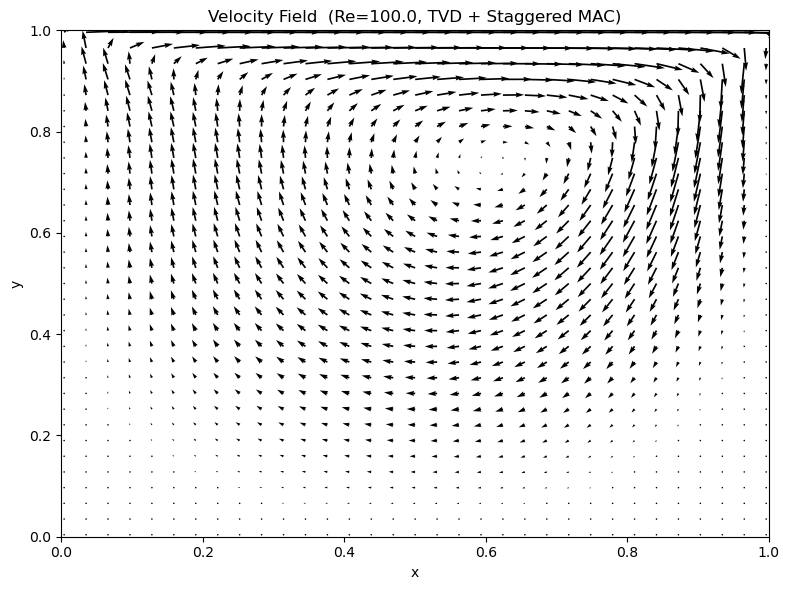

In [11]:
# Interpolate face velocities to cell centres for plotting
u_cell = (u[:, :-1] + u[:, 1:]) / 2   # (N, N)
v_cell = (v[:-1, :] + v[1:, :]) / 2   # (N, N)

step = 4
plt.figure(figsize=(8, 6))
plt.title(f"Velocity Field  (Re={Re}, TVD + Staggered MAC)")
plt.quiver(X_c[::step, ::step], Y_c[::step, ::step], u_cell[::step, ::step], v_cell[::step, ::step])
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, L); plt.ylim(0, L)
plt.tight_layout(); plt.show()

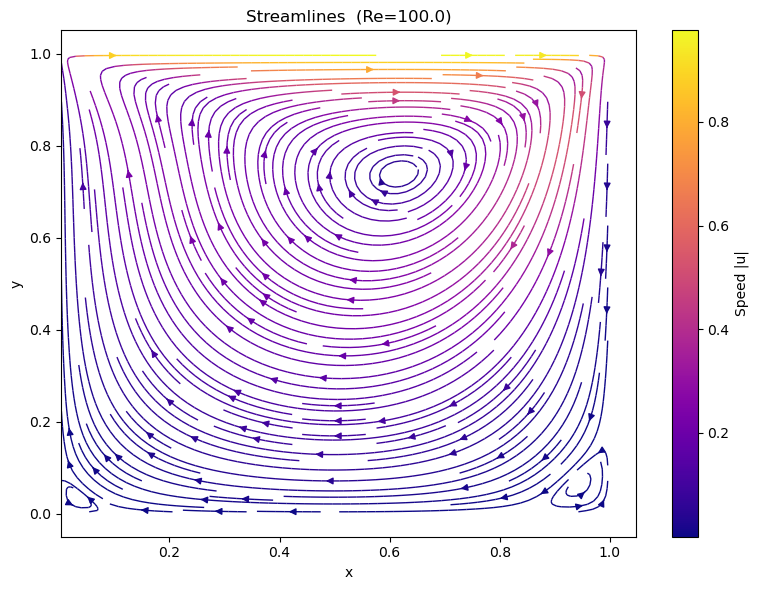

In [12]:
u_cell = (u[:, :-1] + u[:, 1:]) / 2
v_cell = (v[:-1, :] + v[1:, :]) / 2
speed  = np.sqrt(u_cell**2 + v_cell**2)
plt.figure(figsize=(8, 6))
plt.title(f"Streamlines  (Re={Re})")
plt.streamplot(x_c, y_c, u_cell, v_cell, density=2, color=speed, cmap='plasma', linewidth=1)
plt.colorbar(label='Speed |u|')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

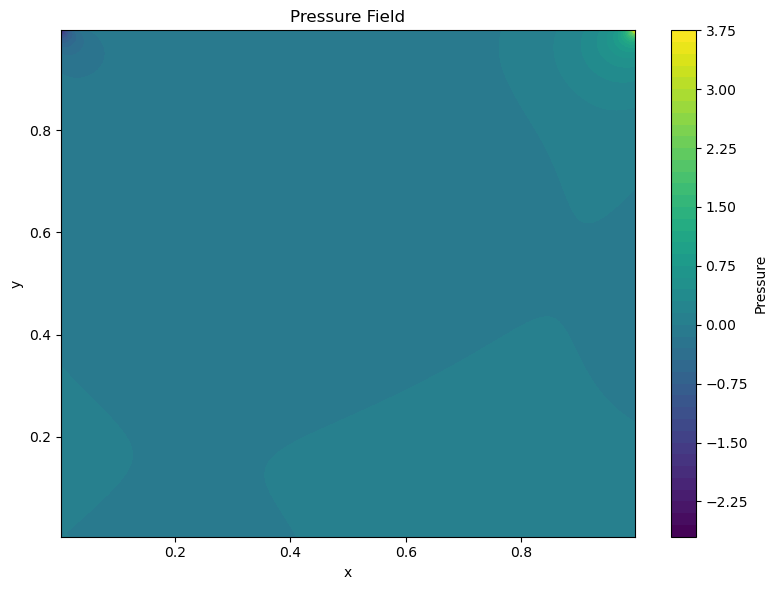

In [13]:
plt.figure(figsize=(8, 6))
plt.title("Pressure Field")
plt.contourf(X_c, Y_c, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

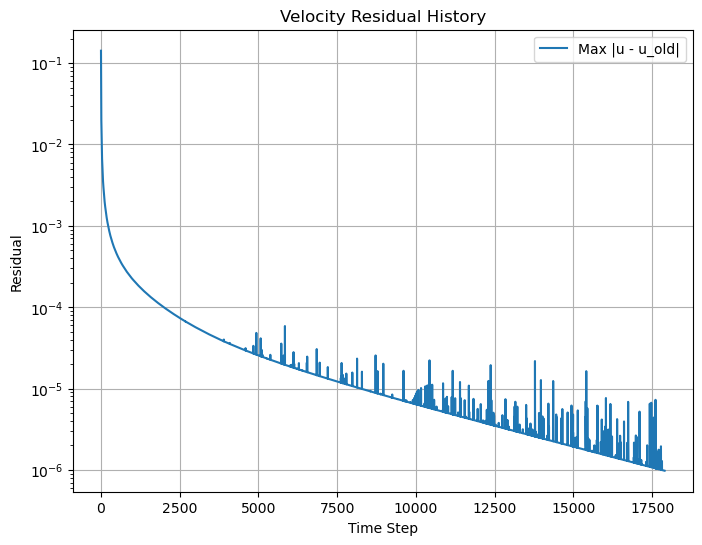

In [14]:
# Velocity Residual Plot
plt.figure(figsize=(8, 6))
plt.title("Velocity Residual History")
plt.semilogy(residual_history, label='Max |u - u_old|')
plt.xlabel('Time Step')
plt.ylabel('Residual')
plt.grid()
plt.legend()
plt.show()

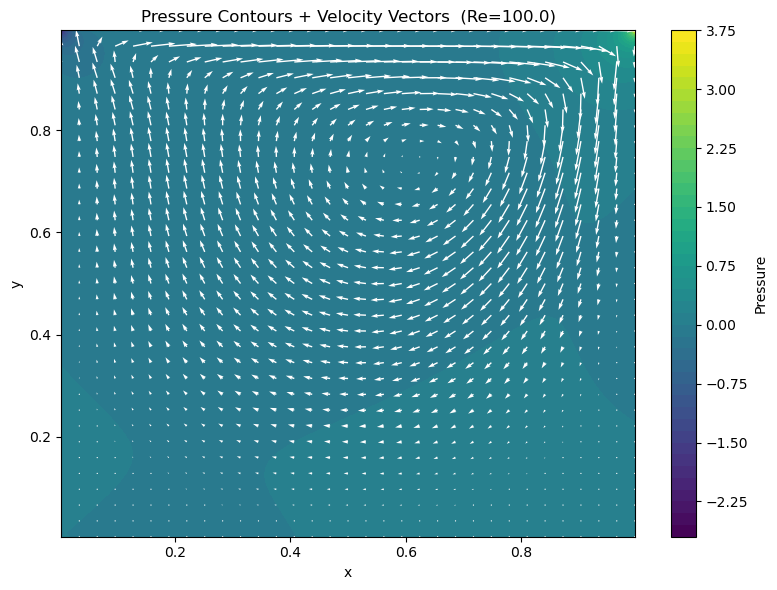

In [15]:
u_cell = (u[:, :-1] + u[:, 1:]) / 2
v_cell = (v[:-1, :] + v[1:, :]) / 2
step = 4
plt.figure(figsize=(8, 6))
plt.title(f"Pressure Contours + Velocity Vectors  (Re={Re})")
plt.contourf(X_c, Y_c, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.quiver(X_c[::step, ::step], Y_c[::step, ::step],
           u_cell[::step, ::step], v_cell[::step, ::step],
           color='white', scale=10)
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

## Validation: Ghia et al. (1982) Benchmark

Compare centerline velocity profiles against the landmark paper:
**Ghia, Ghia & Shin (1982)** — *High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method*

- **u along x = 0.5** (vertical centerline): captures primary vortex strength
- **v along y = 0.5** (horizontal centerline): captures left/right recirculation

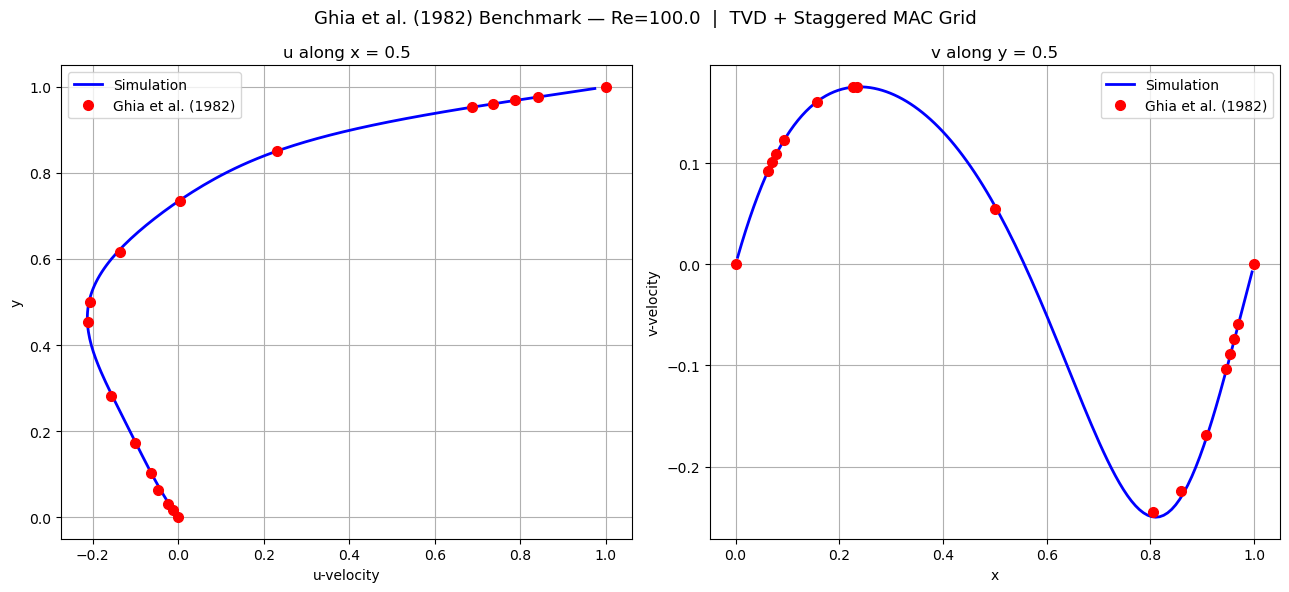

In [16]:
# Ghia et al. (1982) Re=100 benchmark data
ghia_y = [0.0000, 0.0156, 0.0313, 0.0625, 0.1016, 0.1719, 0.2813, 0.4531,
          0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]
ghia_u = [0.00000, -0.01160, -0.02347, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090,
          -0.20581, -0.13641,  0.00332,  0.23151,  0.68717,  0.73722,  0.78871,  0.84123, 1.00000]

ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344,
          0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]
ghia_v = [0.00000,  0.09233,  0.10091,  0.10890,  0.12317,  0.16077,  0.17507,  0.17527,
          0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]

# Staggered grid: face positions (not cell centres)
y_u = (np.arange(N) + 0.5) * dy   # y-position of u-faces
x_v = (np.arange(N) + 0.5) * dx   # x-position of v-faces

# N is the number of CELLS here (can be odd), so no u-face column or
# v-face row sits exactly at x=0.5 / y=0.5 in general. Linearly interpolate
# between the two nearest faces instead of assuming N//2 lands exactly on center.
x_target = 0.5 * L
j_lo = int(np.floor(x_target / dx)); j_hi = min(j_lo + 1, N)
wx = (x_target - j_lo * dx) / dx
u_centerline = (1 - wx) * u[:, j_lo] + wx * u[:, j_hi]

y_target = 0.5 * L
i_lo = int(np.floor(y_target / dy)); i_hi = min(i_lo + 1, N)
wy = (y_target - i_lo * dy) / dy
v_centerline = (1 - wy) * v[i_lo, :] + wy * v[i_hi, :]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Ghia et al. (1982) Benchmark — Re={Re}  |  TVD + Staggered MAC Grid", fontsize=13)

ax1.plot(u_centerline, y_u, "-b", linewidth=2, label="Simulation")
ax1.plot(ghia_u, ghia_y, "ro", markersize=7, label="Ghia et al. (1982)")
ax1.set_xlabel("u-velocity"); ax1.set_ylabel("y")
ax1.set_title("u along x = 0.5")
ax1.legend(); ax1.grid(True)

ax2.plot(x_v, v_centerline, "-b", linewidth=2, label="Simulation")
ax2.plot(ghia_x, ghia_v, "ro", markersize=7, label="Ghia et al. (1982)")
ax2.set_xlabel("x"); ax2.set_ylabel("v-velocity")
ax2.set_title("v along y = 0.5")
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()